### Datos Sintéticos
### libreria SDV
*Fecha: 05 de junio*
*Autor : Daniel Eduardo Pizarro Macuixtle

In [1]:
import pandas as pd
import numpy as no
import random

In [2]:
import sdv
import sdmetrics

In [3]:
# Importamos sublibrerias para la geracion de datos
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [4]:
from sdmetrics.reports.single_table import QualityReport

In [5]:
print("SDV:" ,sdv.__version__)
print("SDMretrics: ", sdmetrics.__version__)

SDV: 1.37.0
SDMretrics:  0.28.0


In [6]:
dfClientes = pd.DataFrame(
    {
        "cliente_id" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "edad" : [17, 18, 19, 25, 32, 42, 70, 28, 23, 22],
        "ingreso_mensual" : [1800, 2000, 2500, 15000, 18000, 35000, 7000, 15000, 4000, 5000],
        # Agregué "Veracruz" al final para completar los 10 elementos
        "ciudad" : ["Potrero Nuevo", "Atoyac", "Cuichapa", "Cordoba", "Cuitlahuac", "Orizaba", "Yanga", "Tierra Blanca", "Calcahualco", "Veracruz"]
    }
)

print(dfClientes)

   cliente_id  edad  ingreso_mensual         ciudad
0           1    17             1800  Potrero Nuevo
1           2    18             2000         Atoyac
2           3    19             2500       Cuichapa
3           4    25            15000        Cordoba
4           5    32            18000     Cuitlahuac
5           6    42            35000        Orizaba
6           7    70             7000          Yanga
7           8    28            15000  Tierra Blanca
8           9    23             4000    Calcahualco
9          10    22             5000       Veracruz


In [7]:
dfClientes

,cliente_id,edad,ingreso_mensual,ciudad
0,1,17,1800,Potrero Nuevo
1,2,18,2000,Atoyac
2,3,19,2500,Cuichapa
3,4,25,15000,Cordoba
4,5,32,18000,Cuitlahuac
5,6,42,35000,Orizaba
6,7,70,7000,Yanga
7,8,28,15000,Tierra Blanca
8,9,23,4000,Calcahualco
9,10,22,5000,Veracruz


In [8]:
metadata = SingleTableMetadata()

In [9]:
metadata.detect_from_dataframe(
    data= dfClientes
)

In [10]:
metadata.to_dict()

{'primary_key': 'cliente_id',
 'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}},
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}

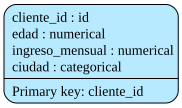

In [11]:
metadata.visualize()

In [14]:
# Le pasamos los metadatos
sintetizador = GaussianCopulaSynthesizer(
    metadata
)

In [15]:
sintetizador.fit(
    dfClientes
)

In [20]:
dfClientes_falsos = sintetizador.sample(
    num_rows= 200
)

In [22]:
dfClientes_falsos.head()

,cliente_id,edad,ingreso_mensual,ciudad
0,7184830,18,5432,Tierra Blanca
1,12096169,62,30492,Veracruz
2,16379368,32,34157,Calcahualco
3,12380438,18,6297,Cuichapa
4,11206626,18,2389,Tierra Blanca


In [23]:
dfClientes_falsos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cliente_id       200 non-null    int64 
 1   edad             200 non-null    int64 
 2   ingreso_mensual  200 non-null    int64 
 3   ciudad           200 non-null    object
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [24]:
dfClientes_falsos.describe()

,cliente_id,edad,ingreso_mensual
count,2.000000e+02,200.000000,200.000000
mean,8.432697e+06,27.055000,11009.475000
std,5.059527e+06,14.334201,10022.425084
min,5.092900e+04,18.000000,2000.000000
25%,3.759651e+06,18.000000,2784.250000
50%,8.251640e+06,19.000000,6446.000000
75%,1.287896e+07,30.000000,17416.500000
max,1.674342e+07,70.000000,35000.000000


In [25]:
dfClientes.describe()

,cliente_id,edad,ingreso_mensual
count,10.00000,10.000000,10.000000
mean,5.50000,29.600000,10530.000000
std,3.02765,16.063762,10507.568701
min,1.00000,17.000000,1800.000000
25%,3.25000,19.750000,2875.000000
50%,5.50000,24.000000,6000.000000
75%,7.75000,31.000000,15000.000000
max,10.00000,70.000000,35000.000000


# Evaluamos los datos a validar
1. Parecido entre columnas(Columns Shapes)
2. Parecido entre las relaciones de las columnas (Evaluating Colum PerTrends)
3. Evaluacion del dataset general

In [35]:
#Evaluacion de la calidad de los datos
#Creamos una instancia de QualityReport
reporte = QualityReport()

## Puntos de referencia
|Score    |Interpretacion|
|---------|--------------|
|1 | Identicas|
|0.9 | Muy Similar|
|0.7 | Similar|
|0.6 | Diferencias Visibles|
|< 0.5 | Muy diferentes|


In [36]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data = dfClientes_falsos,
    metadata= metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 26.69it/s]|
Column Shapes Score: 76.17%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 27.89it/s]|
Column Pair Trends Score: 19.25%

Overall Score (Average): 47.71%

